In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Correlation with SPEED for turn 2:
Steer      -0.018920
Brake      -0.012218
Throttle    0.448152
Gear        0.916856
dtype: float64


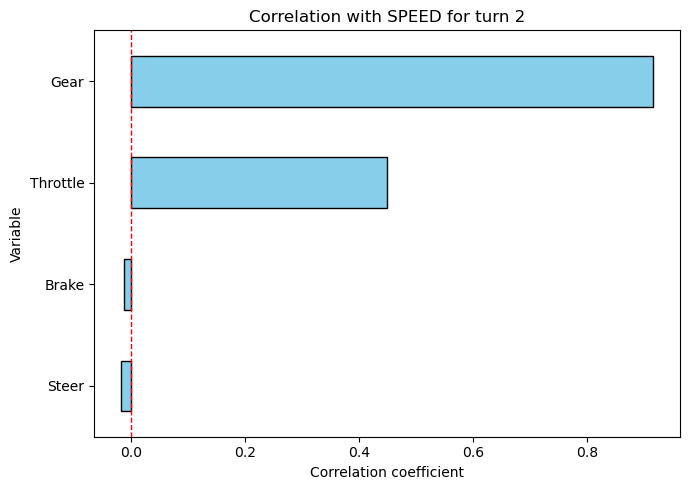

In [3]:
use_cols = [
    "Speed", "Throttle", "Brake", "Steer", "Gear"
]

df = pd.read_csv("turn_2_stats.csv", usecols=use_cols, low_memory=False)

corr_with_speed = {}
for col in use_cols:
    if col != "Speed":
        corr = df[["Speed", col]].corr().iloc[0, 1]
        corr_with_speed[col] = corr

corr_series = pd.Series(corr_with_speed).sort_values()

print("Correlation with SPEED for turn 2:")
print(corr_series)

plt.figure(figsize=(7,5))
corr_series.plot(kind="barh", color="skyblue", edgecolor="black")
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.title("Correlation with SPEED for turn 2")
plt.xlabel("Correlation coefficient")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

=== Correlation with Turn 2 Speed ===
          Turn 1  Mid Point  Brake Point  Turn 2
Throttle   0.245      0.520       -0.172   0.448
Brake     -0.179     -0.080        0.348  -0.012
Steer     -0.153     -0.124       -0.119  -0.019
Gear       0.210      0.573        0.079   0.917


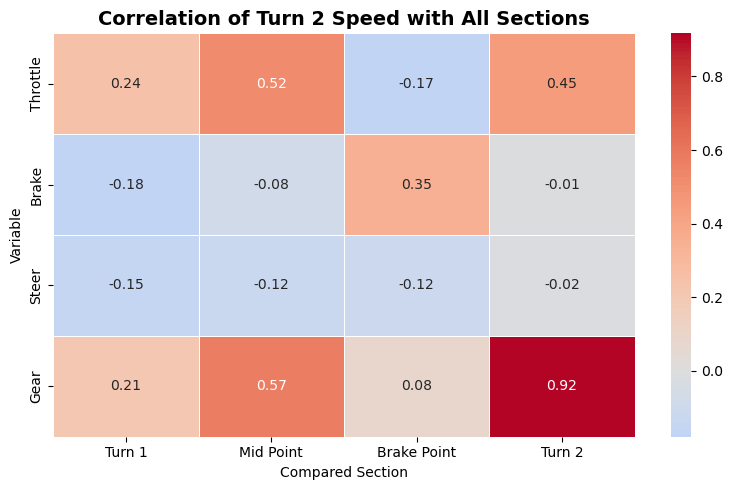

In [11]:

turn1 = pd.read_csv("turn_1_stats.csv")
mid = pd.read_csv("mid_point_stats.csv")
brake = pd.read_csv("brake_point_stats.csv")
turn2 = pd.read_csv("turn_2_stats.csv")

for df in [turn1, mid, brake, turn2]:
    df.columns = df.columns.str.strip()

cols_to_compare = ["Throttle", "Brake", "Steer", "Gear"]

if "Speed" not in turn2.columns:
    raise KeyError("Column 'Speed' not found in turn_2_stats.csv")

speed_turn2 = turn2["Speed"]

def compute_corr(speed_series, df, df_name):
    corr_result = {}
    for col in cols_to_compare:
        if col in df.columns:
            combined = pd.concat([speed_series, df[col]], axis=1).dropna()
            corr = combined.corr().iloc[0, 1]
            corr_result[col] = corr
        else:
            corr_result[col] = None
    return pd.Series(corr_result, name=df_name)

corr_turn1 = compute_corr(speed_turn2, turn1, "Turn 1")
corr_mid = compute_corr(speed_turn2, mid, "Mid Point")
corr_brake = compute_corr(speed_turn2, brake, "Brake Point")
corr_turn2 = compute_corr(speed_turn2, turn2, "Turn 2")  

corr_table = pd.concat([corr_turn1, corr_mid, corr_brake, corr_turn2], axis=1)
corr_table = corr_table.round(3)

print("=== Correlation with Turn 2 Speed ===")
print(corr_table)

corr_table.to_csv("correlation_with_turn2_speed.csv")

plt.figure(figsize=(8, 5))
sns.heatmap(
    corr_table,
    annot=True,          
    fmt=".2f",
    cmap="coolwarm", 
    center=0,
    linewidths=0.5
)
plt.title("Correlation of Turn 2 Speed with All Sections", fontsize=14, weight="bold")
plt.ylabel("Variable")
plt.xlabel("Compared Section")
plt.tight_layout()
plt.show()
